<a href="https://colab.research.google.com/github/incerahmaniaamirniar-creator/Project_RPL/blob/main/Mini_Project_Pengolahan_Citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**BAGIAN A — PERSIAPAN GOOGLE COLAB**

**Cell 1 — Import library**

In [38]:

# =====================================
# MINIPROJECT DETEKSI TANDA TANGAN DEKAN
# =====================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

from google.colab import files

print("Library berhasil diimport!")
print("Versi OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

Library berhasil diimport!
Versi OpenCV: 4.14.0
NumPy: 2.1.3


**Cell 2 — Upload dataset**

In [39]:
import glob
import os

image_paths = sorted(glob.glob("dataset/*"))

print("Jumlah gambar:", len(image_paths))

for i, path in enumerate(image_paths, 1):
    print(i, os.path.basename(path))

Jumlah gambar: 11
1 01_HighQuality_Enhanced.jpg.jpeg
2 02_LowContrast.jpg.jpeg
3 03_Blurred.jpg.jpeg
4 04_HighNoise.jpg.jpeg
5 05_LowResolution_Upsampled.jpg.jpeg
6 06_Faded_Underexposed.jpg.jpeg
7 07_ColorShift_WarmTint.jpg.jpeg
8 08_JPEGCompression_Artifacts.jpg.jpeg
9 09_CombinedDegradation.jpg.jpeg
10 absen
11 absent


**Cell 3 — Menampilkan semua citra asli**

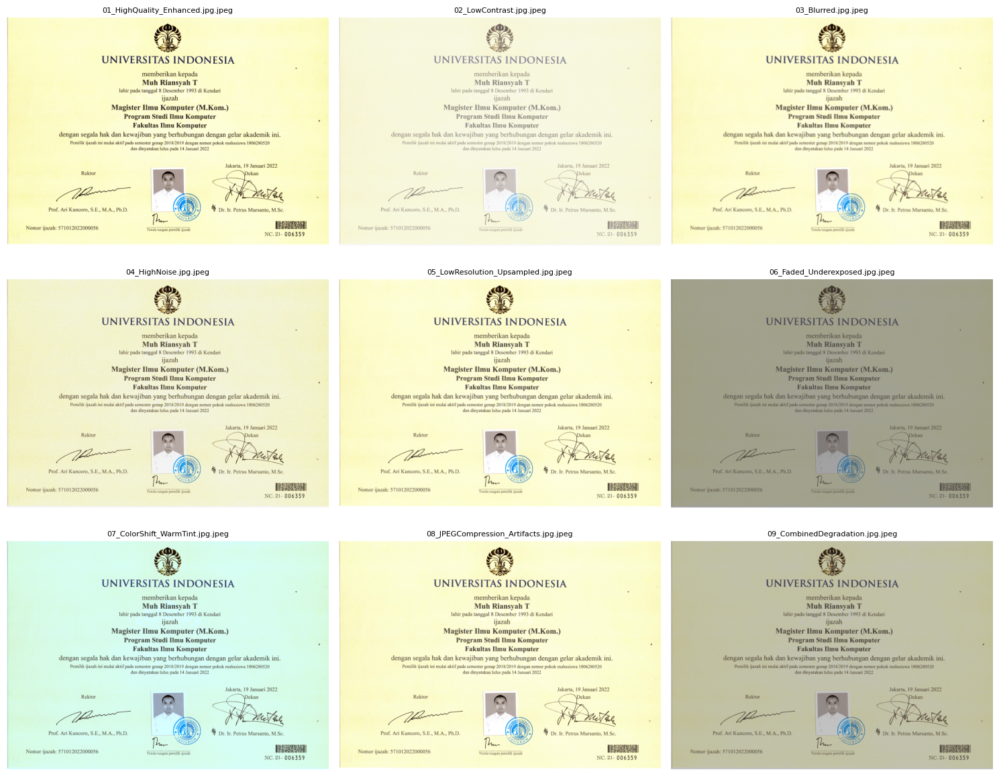

In [41]:

# Menampilkan dataset

plt.figure(figsize=(15, 12))

for i, path in enumerate(image_paths):
    img = cv2.imread(path)

    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(os.path.basename(path), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

**BAGIAN B — CROP TANDA TANGAN DEKAN**

**Ini bagian penting, karena seluruh pengolahan citra selanjutnya akan menggunakan area tanda tangan Dekan.**

**Cell 4 — Crop ROI tanda tangan Dekan**

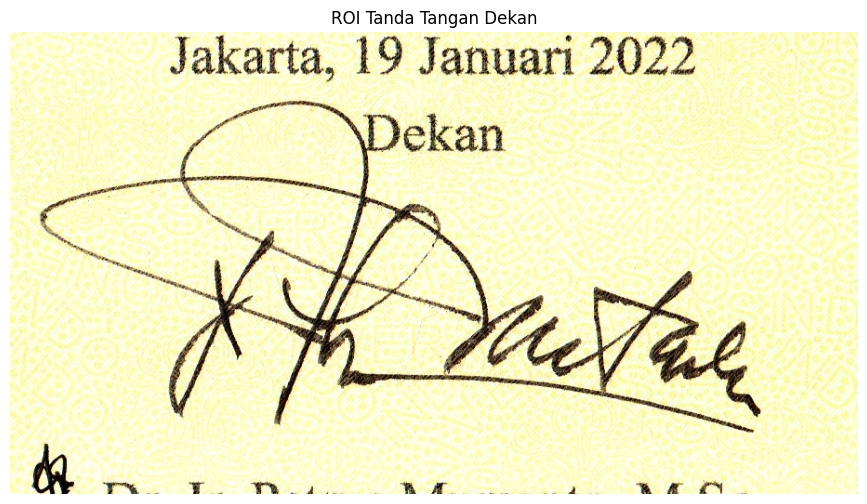

Ukuran ROI: (497, 912, 3)


In [9]:

# Membaca gambar pertama
img = cv2.imread(image_paths[0])

tinggi, lebar = img.shape[:2]

# Area tanda tangan Dekan
x1 = int(lebar * 0.63)
x2 = int(lebar * 0.89)

y1 = int(tinggi * 0.64)
y2 = int(tinggi * 0.84)

# Crop ROI
roi = img[y1:y2, x1:x2]

# Konversi ke RGB untuk ditampilkan
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(roi_rgb)
plt.title("ROI Tanda Tangan Dekan")
plt.axis("off")
plt.show()

print("Ukuran ROI:", roi.shape)

**Cell 5 — Menampilkan hasil crop seluruh dataset**

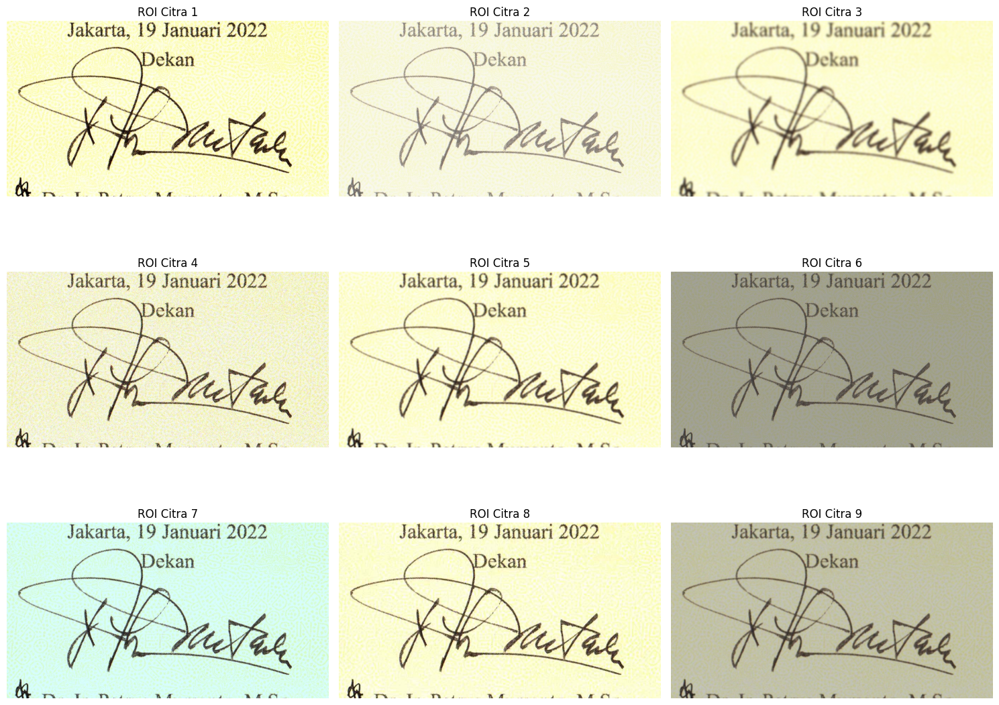

In [10]:

# Crop area yang sama pada semua citra

roi_images = []

for path in image_paths:
    img = cv2.imread(path)

    h, w = img.shape[:2]

    x1 = int(w * 0.63)
    x2 = int(w * 0.89)
    y1 = int(h * 0.64)
    y2 = int(h * 0.84)

    roi = img[y1:y2, x1:x2]

    roi_images.append(roi)

# Visualisasi seluruh ROI
plt.figure(figsize=(15, 12))

for i, roi in enumerate(roi_images):
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(roi_rgb)
    plt.title(f"ROI Citra {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**BAGIAN C — PREPROCESSING**

**Setelah ROI sudah benar, kita masuk ke grayscale.**

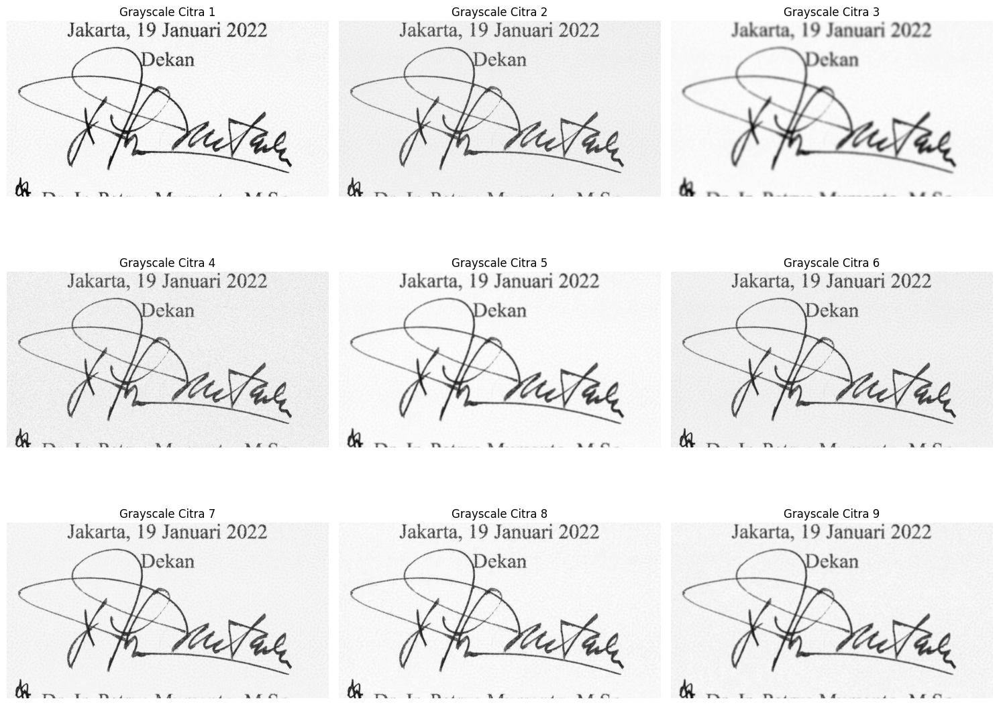

Jumlah citra grayscale: 9


In [11]:
# ==========================================
# CELL 6 - KONVERSI GRAYSCALE
# ==========================================

gray_images = []

# Konversi seluruh ROI menjadi grayscale
for roi in roi_images:

    gray = cv2.cvtColor(
        roi,
        cv2.COLOR_BGR2GRAY
    )

    gray_images.append(gray)


# Menampilkan seluruh citra grayscale
plt.figure(figsize=(15, 12))

for i, gray in enumerate(gray_images):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        gray,
        cmap="gray"
    )

    plt.title(
        f"Grayscale Citra {i+1}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "Jumlah citra grayscale:",
    len(gray_images)
)

Konversi grayscale dilakukan untuk mengubah citra berwarna menjadi citra keabuan sehingga proses thresholding dapat dilakukan berdasarkan intensitas piksel, bukan perbedaan warna.

**BAGIAN D — THRESHOLDING**

**Kita akan menggunakan tiga metode agar hasilnya dapat dibandingkan.**

**Cell 7 — Global Threshold**

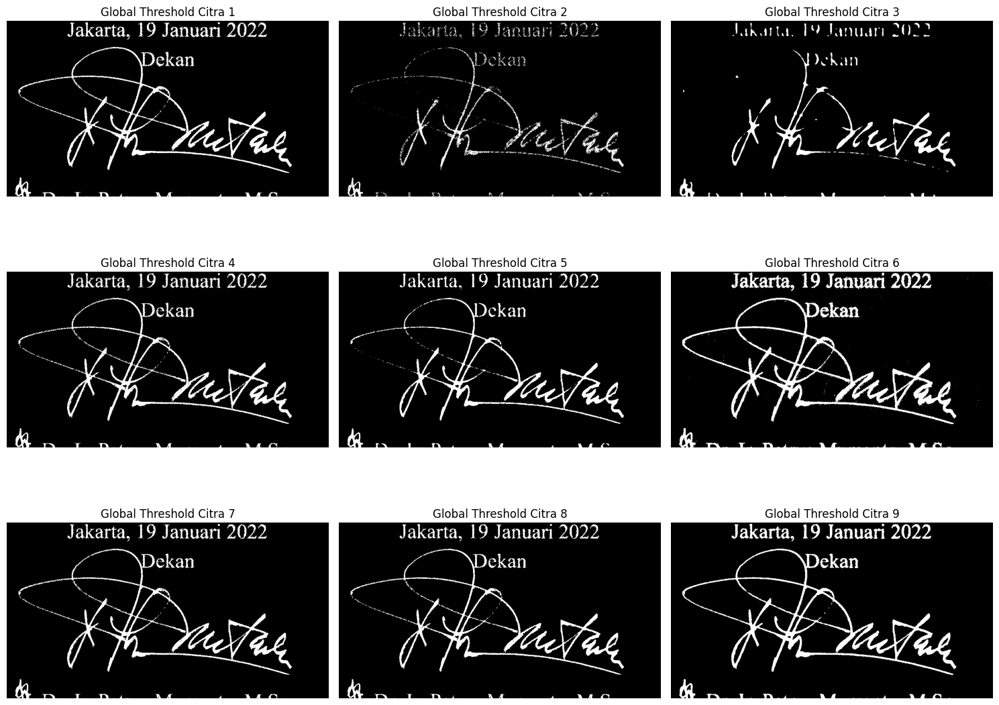

Jumlah hasil Global Threshold: 9


In [12]:

# =====================================
# GLOBAL THRESHOLD PADA 9 CITRA
# =====================================

global_images = []

for gray in gray_images:

    _, thresh = cv2.threshold(
        gray,
        150,
        255,
        cv2.THRESH_BINARY_INV
    )

    global_images.append(thresh)

# Menampilkan hasil seluruh citra
plt.figure(figsize=(15, 12))

for i, thresh in enumerate(global_images):

    plt.subplot(3, 3, i + 1)
    plt.imshow(thresh, cmap="gray")
    plt.title(f"Global Threshold Citra {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Jumlah hasil Global Threshold:", len(global_images))

**Cell 8 — Otsu Threshold**

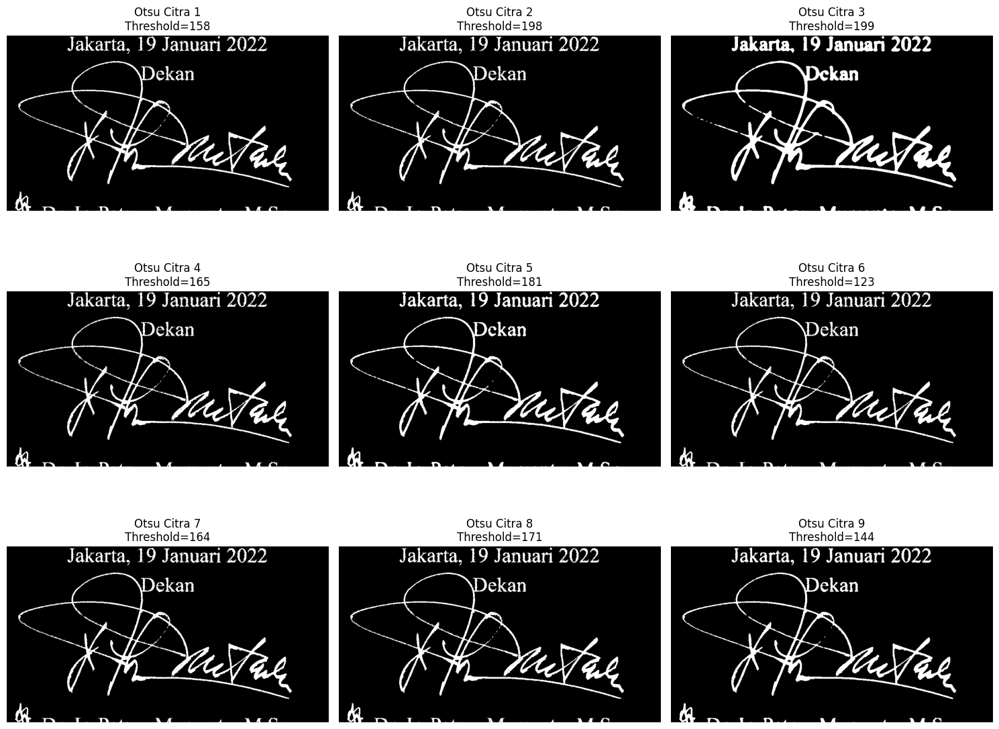

Jumlah hasil Otsu: 9


In [13]:

# =====================================
# OTSU THRESHOLD PADA 9 CITRA
# =====================================

otsu_images = []
otsu_values = []

for gray in gray_images:

    nilai, thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    otsu_images.append(thresh)
    otsu_values.append(nilai)

# Visualisasi
plt.figure(figsize=(15, 12))

for i, thresh in enumerate(otsu_images):

    plt.subplot(3, 3, i + 1)
    plt.imshow(thresh, cmap="gray")
    plt.title(f"Otsu Citra {i+1}\nThreshold={otsu_values[i]:.0f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Jumlah hasil Otsu:", len(otsu_images))

**Cell 9 — Adaptive Threshold**

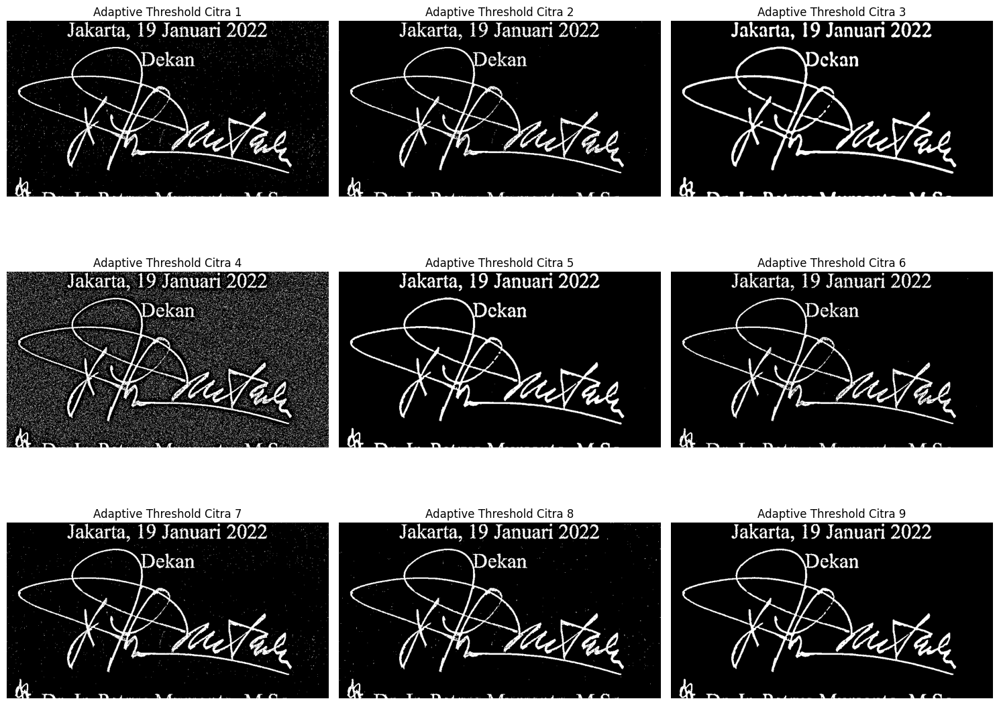

Jumlah hasil Adaptive Threshold: 9


In [14]:

# ==========================================
# CELL 9 - ADAPTIVE THRESHOLD
# DETEKSI TANDA TANGAN DEKAN
# ==========================================

adaptive_images = []

for gray in gray_images:

    adaptive_thresh = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        10
    )

    adaptive_images.append(adaptive_thresh)


# Menampilkan hasil Adaptive Threshold
plt.figure(figsize=(15, 12))

for i, thresh in enumerate(adaptive_images):

    plt.subplot(3, 3, i + 1)

    plt.imshow(thresh, cmap="gray")

    plt.title(f"Adaptive Threshold Citra {i+1}")

    plt.axis("off")

plt.tight_layout()
plt.show()


print("Jumlah hasil Adaptive Threshold:", len(adaptive_images))

Adaptive Threshold diterapkan untuk memisahkan foreground dan background berdasarkan nilai ambang lokal. Pada penelitian ini, metode Gaussian digunakan untuk menghitung ambang berdasarkan intensitas piksel di lingkungan sekitarnya. Hasil segmentasi berupa citra biner yang digunakan untuk membantu mengidentifikasi goresan tanda tangan Dekan.

**BAGIAN E — MORPHOLOGICAL OPERATION**

**Cell 10 — Morphological Opening**

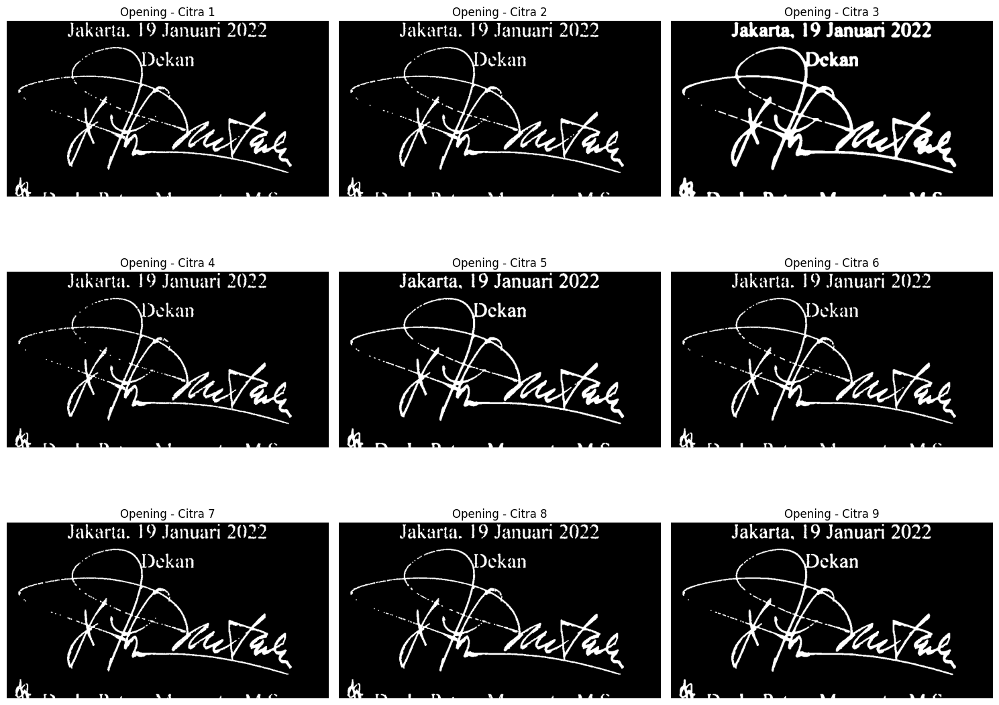

Jumlah hasil Opening: 9


In [15]:
# ==========================================
# CELL 10 - MORPHOLOGICAL OPENING
# ==========================================

# Membuat kernel
kernel = np.ones((3, 3), np.uint8)

opening_images = []

# Opening pada seluruh 9 citra hasil Otsu
for otsu in otsu_images:

    opening = cv2.morphologyEx(
        otsu,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    opening_images.append(opening)

# Menampilkan hasil Opening
plt.figure(figsize=(15, 12))

for i, opening in enumerate(opening_images):

    plt.subplot(3, 3, i + 1)
    plt.imshow(opening, cmap="gray")
    plt.title(f"Opening - Citra {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Jumlah hasil Opening:", len(opening_images))

Morphological Opening digunakan untuk mengurangi noise atau objek kecil yang tidak diperlukan pada hasil segmentasi. Operasi ini dilakukan menggunakan kernel berukuran 3×3 dan satu kali iterasi.

**Cell 11 — Morphological Closing**

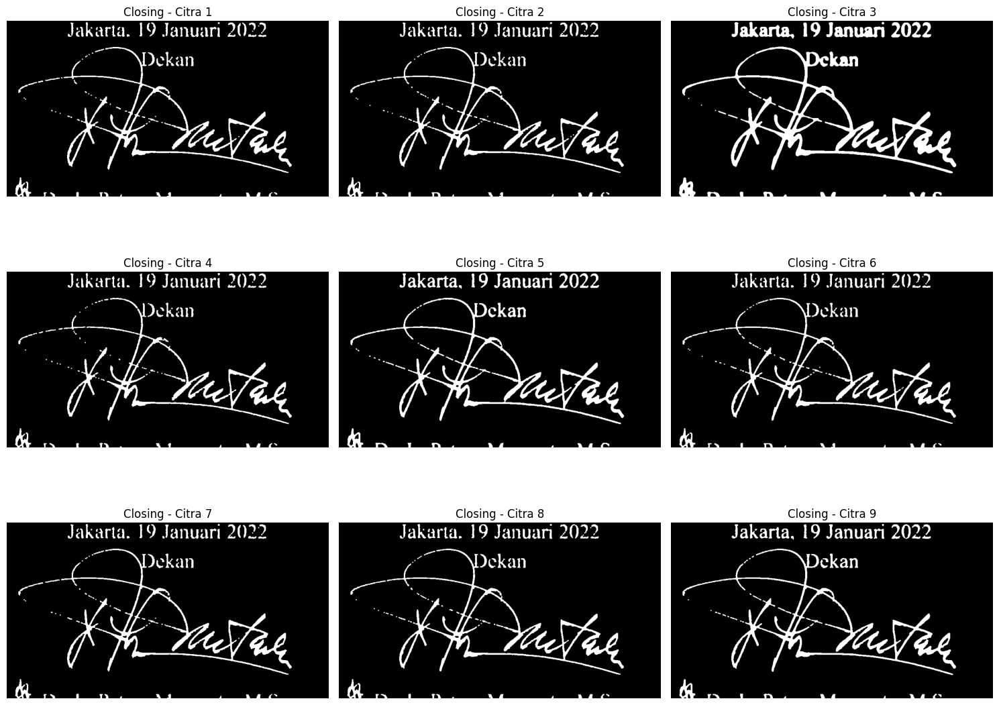

Jumlah hasil Closing: 9


In [16]:
# ==========================================
# CELL 11 - MORPHOLOGICAL CLOSING
# ==========================================

closing_images = []

# Closing dilakukan setelah Opening
for opening in opening_images:

    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    closing_images.append(closing)

# Menampilkan hasil Closing
plt.figure(figsize=(15, 12))

for i, closing in enumerate(closing_images):

    plt.subplot(3, 3, i + 1)
    plt.imshow(closing, cmap="gray")
    plt.title(f"Closing - Citra {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Jumlah hasil Closing:", len(closing_images))

**Cell 12 — Membandingkan Otsu, Opening dan Closing**

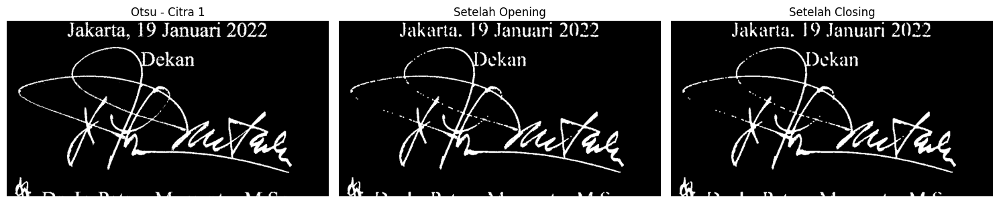

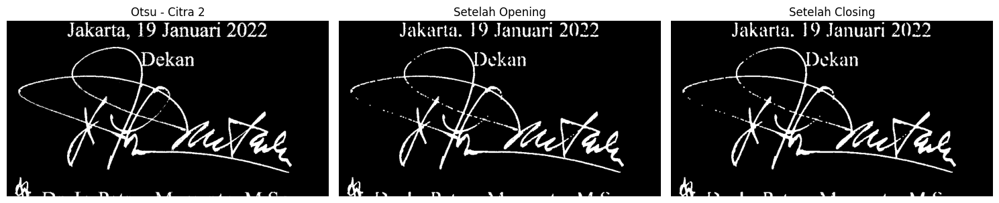

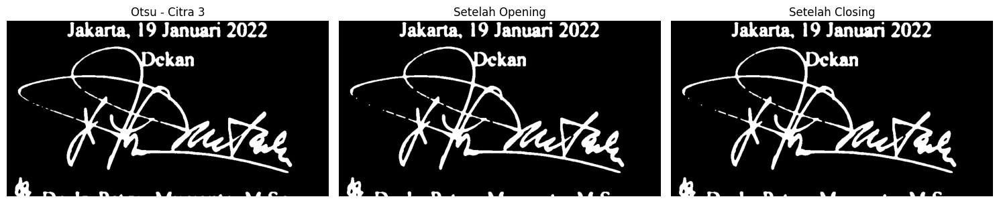

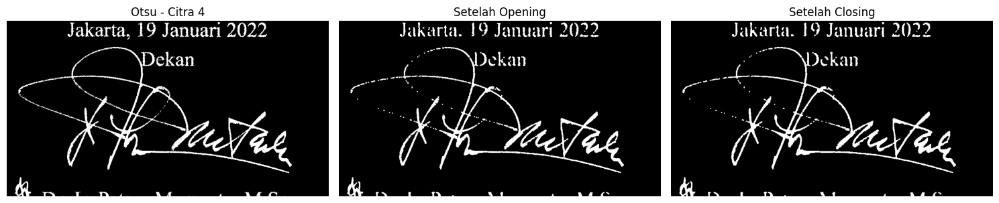

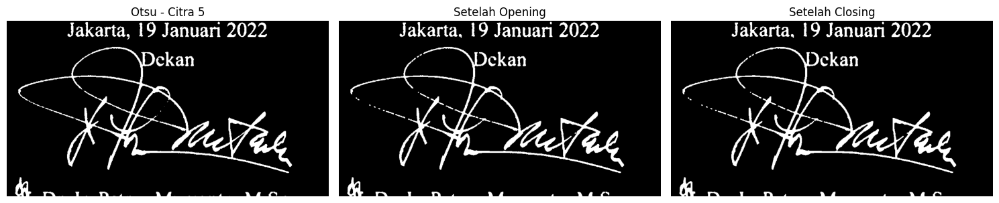

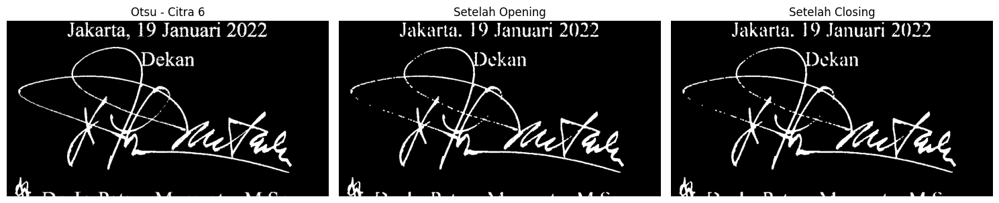

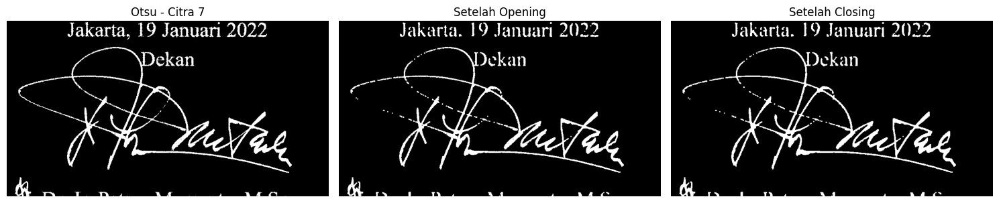

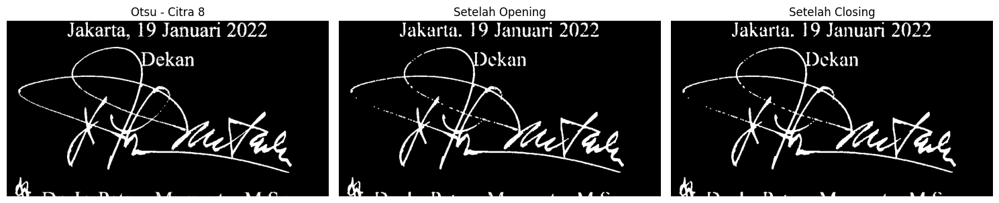

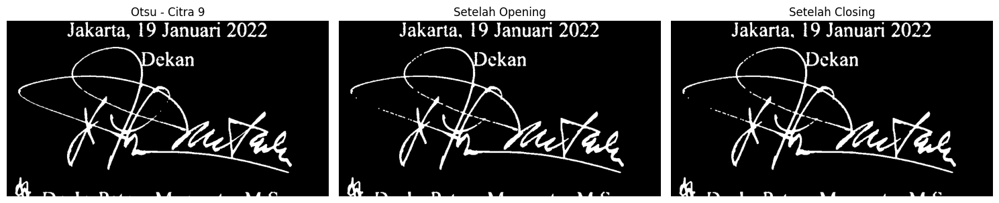

In [17]:
# ==========================================
# CELL 12 - PERBANDINGAN MORPHOLOGY
# ==========================================

for i in range(len(otsu_images)):

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(otsu_images[i], cmap="gray")
    plt.title(f"Otsu - Citra {i+1}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(opening_images[i], cmap="gray")
    plt.title("Setelah Opening")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(closing_images[i], cmap="gray")
    plt.title("Setelah Closing")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Hasil Otsu digunakan sebagai citra awal. Morphological Opening diterapkan untuk mengurangi noise kecil, sedangkan Closing digunakan untuk menutup celah kecil dan membantu mempertahankan bagian objek yang terputus. Hasil akhir digunakan sebagai dasar perhitungan area foreground.

**BAGIAN F — MENGHITUNG KARAKTERISTIK AREA**

Hitung karakteristik area hasil segmentasi, misalnya jumlah piksel foreground.

Kita akan menghitung:

Total piksel ROI
Foreground pixel
Background pixel
Persentase foreground

**Cell 13 — Foreground Pixel**

In [18]:
# ==========================================
# CELL 13 - PERHITUNGAN FOREGROUND
# ==========================================

hasil = []

for i, img in enumerate(closing_images):

    # Total seluruh piksel
    total_pixel = img.size

    # Jumlah piksel foreground
    foreground_pixel = cv2.countNonZero(img)

    # Jumlah background
    background_pixel = total_pixel - foreground_pixel

    # Persentase foreground
    foreground_percentage = (
        foreground_pixel / total_pixel
    ) * 100

    hasil.append({
        "Citra": os.path.basename(image_paths[i]),
        "Total Pixel": total_pixel,
        "Foreground Pixel": foreground_pixel,
        "Background Pixel": background_pixel,
        "Foreground (%)": round(foreground_percentage, 2)
    })

# Membuat tabel
df_hasil = pd.DataFrame(hasil)

display(df_hasil)

,Citra,Total Pixel,Foreground Pixel,Background Pixel,Foreground (%)
0,01_HighQuality_Enhanced.jpg.jpeg,453264,32534,420730,7.18
1,02_LowContrast.jpg.jpeg,453264,33032,420232,7.29
2,03_Blurred.jpg.jpeg,453264,51510,401754,11.36
3,04_HighNoise.jpg.jpeg,453264,31415,421849,6.93
4,05_LowResolution_Upsampled.jpg.jpeg,453264,38805,414459,8.56
5,06_Faded_Underexposed.jpg.jpeg,453264,33121,420143,7.31
6,07_ColorShift_WarmTint.jpg.jpeg,453264,32921,420343,7.26
7,08_JPEGCompression_Artifacts.jpg.jpeg,453264,33696,419568,7.43
8,09_CombinedDegradation.jpg.jpeg,453264,37152,416112,8.20


**BAGIAN G — DATA PRESENT DAN ABSENT**

**Cell 14 — Menyiapkan Data Pengujian**

In [19]:

# ==========================================
# CELL 14 - PERSIAPAN DATA PENGUJIAN
# ==========================================

print("JUMLAH DATA PENGUJIAN")
print("======================")

print("Data SIGNATURE PRESENT:", len(roi_images))

print("\nDaftar citra:")

for i, path in enumerate(image_paths):
    print(f"{i+1}. {os.path.basename(path)}")

print("\nStatus: Data PRESENT berhasil disiapkan.")
print("Data ABSENT: Belum disiapkan.")

JUMLAH DATA PENGUJIAN
Data SIGNATURE PRESENT: 9

Daftar citra:
1. 01_HighQuality_Enhanced.jpg.jpeg
2. 02_LowContrast.jpg.jpeg
3. 03_Blurred.jpg.jpeg
4. 04_HighNoise.jpg.jpeg
5. 05_LowResolution_Upsampled.jpg.jpeg
6. 06_Faded_Underexposed.jpg.jpeg
7. 07_ColorShift_WarmTint.jpg.jpeg
8. 08_JPEGCompression_Artifacts.jpg.jpeg
9. 09_CombinedDegradation.jpg.jpeg

Status: Data PRESENT berhasil disiapkan.
Data ABSENT: Belum disiapkan.


**Cell 15 — Membuat Data SIGNATURE ABSENT**

In [28]:
# ==========================================
# CELL 15 - DATA SIGNATURE ABSENT
# Menggunakan citra asli yang tidak memiliki TTD
# ==========================================

import glob
import os
import cv2

# Folder khusus gambar ABSENT
absent_paths = sorted(glob.glob("dataset/absent/*"))

print("Jumlah citra ABSENT:", len(absent_paths))

# Crop area TTD yang sama seperti data PRESENT
absent_roi_images = []

for path in absent_paths:
    img = cv2.imread(path)

    if img is None:
        print("Gagal membaca:", path)
        continue

    h, w = img.shape[:2]

    # Koordinat crop SAMA dengan Cell 4
    x1 = int(0.63 * w)
    x2 = int(0.89 * w)
    y1 = int(0.64 * h)
    y2 = int(0.84 * h)

    roi = img[y1:y2, x1:x2]

    # Grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    absent_roi_images.append(gray)

print("Citra ABSENT berhasil diproses:", len(absent_roi_images))

Jumlah citra ABSENT: 0
Citra ABSENT berhasil diproses: 0


**Cell 16 — Proses Thresholding Data ABSENT**

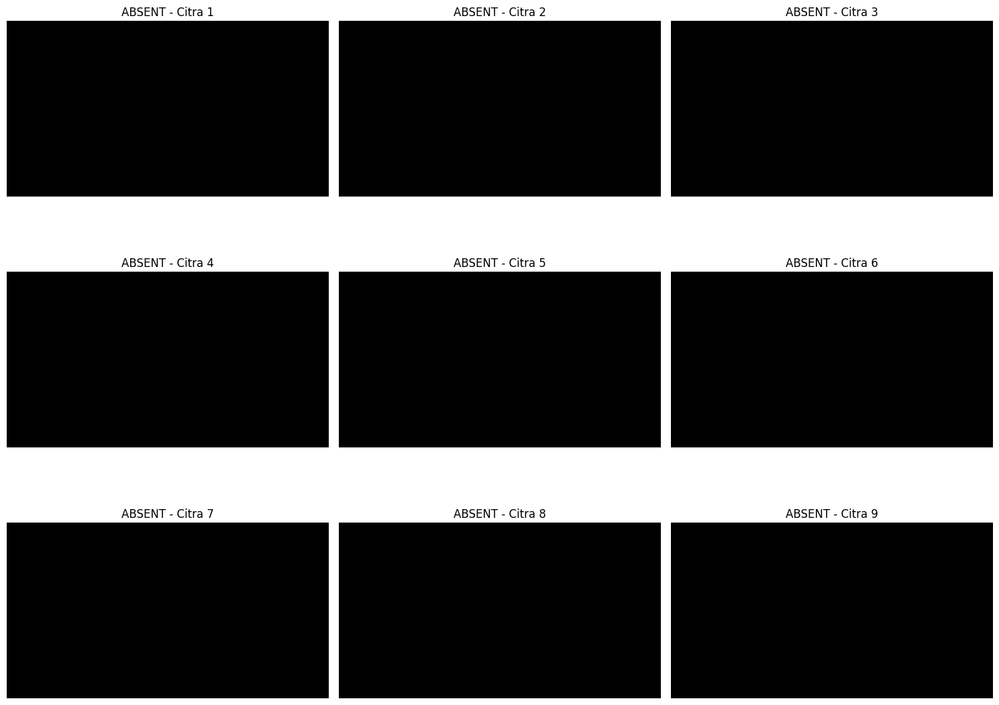

Jumlah hasil segmentasi ABSENT: 9


In [22]:

# ==========================================
# CELL 16 - SEGMENTASI DATA ABSENT
# ==========================================

absent_closing_images = []

for gray in absent_gray_images:

    # Otsu Threshold
    _, absent_otsu = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Morphological Opening
    absent_opening = cv2.morphologyEx(
        absent_otsu,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # Morphological Closing
    absent_closing = cv2.morphologyEx(
        absent_opening,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    absent_closing_images.append(absent_closing)

# Menampilkan hasil
plt.figure(figsize=(15, 12))

for i, img in enumerate(absent_closing_images):

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"ABSENT - Citra {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Jumlah hasil segmentasi ABSENT:", len(absent_closing_images))

**CELL 17: PERHITUNGAN FOREGROUND DATA ABSENT**

In [23]:

# ==========================================
# CELL 17 - PERHITUNGAN FOREGROUND ABSENT
# ==========================================

absent_hasil = []

for i, img in enumerate(absent_closing_images):

    total_pixel = img.size

    foreground_pixel = cv2.countNonZero(img)

    background_pixel = total_pixel - foreground_pixel

    foreground_percentage = (
        foreground_pixel / total_pixel
    ) * 100

    absent_hasil.append({
        "Citra": f"ABSENT {i+1}",
        "Total Pixel": total_pixel,
        "Foreground Pixel": foreground_pixel,
        "Background Pixel": background_pixel,
        "Foreground (%)": round(foreground_percentage, 2),
        "Label Aktual": "SIGNATURE ABSENT"
    })

df_absent = pd.DataFrame(absent_hasil)

display(df_absent)

print("Jumlah data ABSENT:", len(df_absent))

,Citra,Total Pixel,Foreground Pixel,Background Pixel,Foreground (%),Label Aktual
0,ABSENT 1,453264,0,453264,0.0,SIGNATURE ABSENT
1,ABSENT 2,453264,0,453264,0.0,SIGNATURE ABSENT
2,ABSENT 3,453264,0,453264,0.0,SIGNATURE ABSENT
3,ABSENT 4,453264,0,453264,0.0,SIGNATURE ABSENT
4,ABSENT 5,453264,0,453264,0.0,SIGNATURE ABSENT
5,ABSENT 6,453264,0,453264,0.0,SIGNATURE ABSENT
6,ABSENT 7,453264,0,453264,0.0,SIGNATURE ABSENT
7,ABSENT 8,453264,0,453264,0.0,SIGNATURE ABSENT
8,ABSENT 9,453264,0,453264,0.0,SIGNATURE ABSENT


Jumlah data ABSENT: 9


**CELL 18 — MENGGABUNGKAN DATA PRESENT DAN ABSENT**

In [24]:

# ==========================================
# CELL 18 - GABUNG DATA PRESENT DAN ABSENT
# ==========================================

# Mengambil hasil PRESENT dari Cell 13
df_present = df_hasil.copy()

df_present["Label Aktual"] = "SIGNATURE PRESENT"

# Menggabungkan kedua kelompok data
df_pengujian = pd.concat(
    [df_present, df_absent],
    ignore_index=True
)

display(df_pengujian)

print("Total seluruh data:", len(df_pengujian))
print(
    "Jumlah PRESENT:",
    (df_pengujian["Label Aktual"] == "SIGNATURE PRESENT").sum()
)
print(
    "Jumlah ABSENT:",
    (df_pengujian["Label Aktual"] == "SIGNATURE ABSENT").sum()
)

,Citra,Total Pixel,Foreground Pixel,Background Pixel,Foreground (%),Label Aktual
0,01_HighQuality_Enhanced.jpg.jpeg,453264,32534,420730,7.18,SIGNATURE PRESENT
1,02_LowContrast.jpg.jpeg,453264,33032,420232,7.29,SIGNATURE PRESENT
2,03_Blurred.jpg.jpeg,453264,51510,401754,11.36,SIGNATURE PRESENT
3,04_HighNoise.jpg.jpeg,453264,31415,421849,6.93,SIGNATURE PRESENT
4,05_LowResolution_Upsampled.jpg.jpeg,453264,38805,414459,8.56,SIGNATURE PRESENT
5,06_Faded_Underexposed.jpg.jpeg,453264,33121,420143,7.31,SIGNATURE PRESENT
6,07_ColorShift_WarmTint.jpg.jpeg,453264,32921,420343,7.26,SIGNATURE PRESENT
7,08_JPEGCompression_Artifacts.jpg.jpeg,453264,33696,419568,7.43,SIGNATURE PRESENT
8,09_CombinedDegradation.jpg.jpeg,453264,37152,416112,8.20,SIGNATURE PRESENT
9,ABSENT 1,453264,0,453264,0.00,SIGNATURE ABSENT


Total seluruh data: 18
Jumlah PRESENT: 9
Jumlah ABSENT: 9


**Cell 18 — Menentukan Aturan Klasifikasi**

In [25]:

# ==========================================
# CELL 18 - KLASIFIKASI TANDA TANGAN
# ==========================================

# Menentukan batas foreground awal
threshold_batas = 5.0

# Fungsi klasifikasi
def klasifikasi_tanda_tangan(persen):

    if persen >= threshold_batas:
        return "SIGNATURE PRESENT"
    else:
        return "SIGNATURE ABSENT"


# Melakukan prediksi pada seluruh data
df_pengujian["Prediksi"] = df_pengujian[
    "Foreground (%)"
].apply(klasifikasi_tanda_tangan)

# Menampilkan hasil
display(
    df_pengujian[
        [
            "Citra",
            "Foreground (%)",
            "Label Aktual",
            "Prediksi"
        ]
    ]
)

print("Klasifikasi selesai.")

,Citra,Foreground (%),Label Aktual,Prediksi
0,01_HighQuality_Enhanced.jpg.jpeg,7.18,SIGNATURE PRESENT,SIGNATURE PRESENT
1,02_LowContrast.jpg.jpeg,7.29,SIGNATURE PRESENT,SIGNATURE PRESENT
2,03_Blurred.jpg.jpeg,11.36,SIGNATURE PRESENT,SIGNATURE PRESENT
3,04_HighNoise.jpg.jpeg,6.93,SIGNATURE PRESENT,SIGNATURE PRESENT
4,05_LowResolution_Upsampled.jpg.jpeg,8.56,SIGNATURE PRESENT,SIGNATURE PRESENT
5,06_Faded_Underexposed.jpg.jpeg,7.31,SIGNATURE PRESENT,SIGNATURE PRESENT
6,07_ColorShift_WarmTint.jpg.jpeg,7.26,SIGNATURE PRESENT,SIGNATURE PRESENT
7,08_JPEGCompression_Artifacts.jpg.jpeg,7.43,SIGNATURE PRESENT,SIGNATURE PRESENT
8,09_CombinedDegradation.jpg.jpeg,8.20,SIGNATURE PRESENT,SIGNATURE PRESENT
9,ABSENT 1,0.00,SIGNATURE ABSENT,SIGNATURE ABSENT


Klasifikasi selesai.


**Cell 19 — Evaluasi Confusion Matrix**

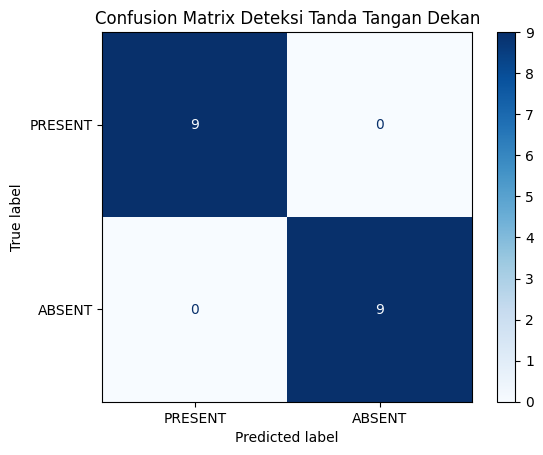

Confusion Matrix:
[[9 0]
 [0 9]]


In [26]:

# ==========================================
# CELL 19 - CONFUSION MATRIX
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Label aktual dan prediksi
y_true = df_pengujian["Label Aktual"]
y_pred = df_pengujian["Prediksi"]

# Menghitung confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "SIGNATURE PRESENT",
        "SIGNATURE ABSENT"
    ]
)

# Menampilkan confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "PRESENT",
        "ABSENT"
    ]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix Deteksi Tanda Tangan Dekan")
plt.show()

print("Confusion Matrix:")
print(cm)

**Cell 20 — Menghitung Akurasi**

In [27]:

# ==========================================
# CELL 20 - EVALUASI AKURASI
# ==========================================

akurasi = accuracy_score(y_true, y_pred)

print("HASIL EVALUASI SISTEM")
print("=====================")

print("Total data pengujian:", len(y_true))

print("Jumlah prediksi benar:",
      (y_true == y_pred).sum())

print("Akurasi sistem: {:.2f}%".format(akurasi * 100))

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[
            "SIGNATURE PRESENT",
            "SIGNATURE ABSENT"
        ],
        zero_division=0
    )
)

HASIL EVALUASI SISTEM
Total data pengujian: 18
Jumlah prediksi benar: 18
Akurasi sistem: 100.00%

Classification Report:
                   precision    recall  f1-score   support

SIGNATURE PRESENT       1.00      1.00      1.00         9
 SIGNATURE ABSENT       1.00      1.00      1.00         9

         accuracy                           1.00        18
        macro avg       1.00      1.00      1.00        18
     weighted avg       1.00      1.00      1.00        18

